# House Price Prediction using Machine Learning

### XYlofy AI Internship – Week 1 Project

**Submitted by:** Shrishti Vaishnav

**Tools Used:** Python, Pandas, Scikit-Learn, Matplotlib, Seaborn

**Objective:** Develop machine learning models to predict house prices based on property characteristics and identify the key factors influencing property valuation.

# Table of Contents

1. Task 1 – Data Loading & Exploration
2. Task 2 – Data Cleaning & Preprocessing
3. Task 3 – Model Building & Benchmarking
4. Task 4 – Data Visualization
5. Task 5 – Insights & Executive Summary
6. Final Conclusion

In [2]:
# TASK 1: DATA LOADING & EXPLORATION

# Import essential python libraries for data manipulation and analytics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Scikit-learn utilities for modeling and metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load the dataset from the local environment
# Ensure 'Housing.csv' is saved in the same directory as this notebook
try:
    df = pd.read_csv('Housing.csv')
    print("[SUCCESS] Housing dataset loaded successfully.\n")
except FileNotFoundError:
    print("[ERROR] 'Housing.csv' not found. Please place the file in the working directory.\n")

# 2. Display the first 10 rows of the dataset to understand the layout
print("--- Displaying the First 10 Rows ---")
display(df.head(10))

# 3. Check structural dimensions (Rows and Columns)
rows, cols = df.shape
print(f"\n--- Dataset Dimensions ---")
print(f"Total Rows (Records)   : {rows}")
print(f"Total Columns (Features): {cols}")

# 4. Target and Feature Identification
print(f"\n--- Variable Definitions ---")
print(f"Target Variable (Y): 'price' (Continuous numeric value we intend to predict)")
features_list = list(df.columns.drop('price'))
print(f"Feature Variables (X): {features_list}")

# 5. Missing Values Verification
print(f"\n--- Checking for Missing/Null Values ---")
missing_data = df.isnull().sum()
print(missing_data)

[SUCCESS] Housing dataset loaded successfully.

--- Displaying the First 10 Rows ---


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



--- Dataset Dimensions ---
Total Rows (Records)   : 545
Total Columns (Features): 13

--- Variable Definitions ---
Target Variable (Y): 'price' (Continuous numeric value we intend to predict)
Feature Variables (X): ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

--- Checking for Missing/Null Values ---
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


# TASK 1: Data Loading & Exploration

## Overview

Data loading and exploration form the foundation of any data science and machine learning project. This stage involves importing the necessary libraries, loading the dataset into the working environment, examining its structure, identifying the target and feature variables, and verifying the quality of the data by checking for missing values.

The objective of this task is to gain an initial understanding of the Housing dataset before performing preprocessing and model development.

---

# 1. Importing Required Libraries

## Code

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
```

## Explanation

Several Python libraries were imported to facilitate data manipulation, visualization, and machine learning.

| Library | Purpose |
|----------------------------|------------------------------------------------|
| **Pandas (`pd`)** | Used for loading and manipulating tabular data using DataFrames. |
| **NumPy (`np`)** | Provides numerical computing functions and array operations. |
| **Matplotlib (`plt`)** | Used for creating plots and visualizations. |
| **Seaborn (`sns`)** | Provides advanced statistical data visualizations. |
| **train_test_split** | Splits the dataset into training and testing subsets. |
| **LinearRegression** | Implements the Linear Regression algorithm. |
| **RandomForestRegressor** | Implements the Random Forest Regression algorithm. |
| **Regression Metrics** | Used to evaluate model performance using MAE, RMSE, and R². |

These libraries provide all the necessary tools for data preprocessing, model building, and performance evaluation.

---

# 2. Loading the Dataset

## Code

```python
try:
    df = pd.read_csv('Housing.csv')
    print("[SUCCESS] Housing dataset loaded successfully.")
except FileNotFoundError:
    print("[ERROR] 'Housing.csv' not found.")
```

## Output

```
[SUCCESS] Housing dataset loaded successfully.
```

## Explanation

The Housing dataset was loaded into a Pandas DataFrame using the `read_csv()` function.

A `try-except` block was implemented to improve program robustness:

- If the dataset exists in the working directory, it is loaded successfully.
- If the file is missing, an informative error message is displayed instead of terminating the program unexpectedly.

This approach makes the code more reliable and user-friendly.

---

# 3. Displaying the First 10 Records

## Code

```python
display(df.head(10))
```

## Output

| price | area | bedrooms | bathrooms | stories | mainroad | guestroom | basement | hotwaterheating | airconditioning | parking | prefarea | furnishingstatus |
|------------|------|-----------|------------|----------|-----------|-------------|-------------|------------------|-------------------|-----------|-------------|----------------|
| 13300000 | 7420 | 4 | 2 | 3 | yes | no | no | no | yes | 2 | yes | furnished |
| 12250000 | 8960 | 4 | 4 | 4 | yes | no | no | no | yes | 3 | no | furnished |
| 12250000 | 9960 | 3 | 2 | 2 | yes | no | yes | no | no | 2 | yes | semi-furnished |
| 12215000 | 7500 | 4 | 2 | 2 | yes | no | yes | no | yes | 3 | yes | furnished |
| 11410000 | 7420 | 4 | 1 | 2 | yes | yes | yes | no | yes | 2 | no | furnished |
| 10850000 | 7500 | 3 | 3 | 1 | yes | no | yes | no | yes | 2 | yes | semi-furnished |
| 10150000 | 8580 | 4 | 3 | 4 | yes | no | no | no | yes | 2 | yes | semi-furnished |
| 10150000 | 16200 | 5 | 3 | 2 | yes | no | no | no | no | 0 | no | unfurnished |
| 9870000 | 8100 | 4 | 1 | 2 | yes | yes | yes | no | yes | 2 | yes | furnished |
| 9800000 | 5750 | 3 | 2 | 4 | yes | yes | no | no | yes | 1 | yes | unfurnished |

## Explanation

The `head(10)` function displays the first ten observations of the dataset.

This initial exploration helps to:

- Understand the overall structure of the dataset.
- Identify the available features.
- Verify that the data has been loaded correctly.
- Observe the different numerical and categorical variables.

From the displayed records, it is evident that the dataset contains both quantitative features (such as area, bedrooms, bathrooms, and parking) and qualitative features (such as main road access, furnishing status, and air conditioning availability).

---

# 4. Dataset Dimensions

## Code

```python
rows, cols = df.shape

print(f"Total Rows: {rows}")
print(f"Total Columns: {cols}")
```

## Output

```
Total Rows (Records)   : 545
Total Columns (Features): 13
```

## Explanation

The `shape` attribute returns the dimensions of the dataset.

### Interpretation

- **Total Records (Rows): 545**
  - Each row represents a unique residential property.

- **Total Features (Columns): 13**
  - Each column represents a property attribute or the target variable used for prediction.

The dataset size is suitable for implementing and evaluating regression algorithms while maintaining computational efficiency.

---

# 5. Target and Feature Identification

## Code

```python
features_list = list(df.columns.drop('price'))
```

## Output

```
Target Variable (Y): 'price'

Feature Variables (X):
['area',
 'bedrooms',
 'bathrooms',
 'stories',
 'mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'parking',
 'prefarea',
 'furnishingstatus']
```

## Explanation

Machine learning problems require the identification of:

### Target Variable (Dependent Variable)

```
price
```

This is the variable that the regression models will predict.

It represents the selling price of a house and is a continuous numerical value.

### Feature Variables (Independent Variables)

The remaining twelve columns serve as predictor variables:

| Feature | Description |
|---------------------|--------------------------------------------|
| area | Total area of the house |
| bedrooms | Number of bedrooms |
| bathrooms | Number of bathrooms |
| stories | Number of floors |
| mainroad | Access to the main road |
| guestroom | Availability of a guest room |
| basement | Presence of a basement |
| hotwaterheating | Availability of hot water heating |
| airconditioning | Availability of air conditioning |
| parking | Number of parking spaces |
| prefarea | Located in a preferred area |
| furnishingstatus | Furnishing condition of the house |

These features collectively provide the information required to estimate house prices.

---

# 6. Missing Values Verification

## Code

```python
missing_data = df.isnull().sum()

print(missing_data)
```

## Output

```
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
```

## Explanation

The `isnull()` function identifies missing values in each column, while `sum()` counts their occurrences.

### Interpretation

Every feature contains:

```
0 missing values
```

This indicates that:

- The dataset is complete.
- No records require imputation or removal due to missing information.
- The data is immediately suitable for preprocessing and machine learning.

The absence of missing values improves model reliability and simplifies the preprocessing pipeline.

---

# 7. Summary of Task 1

| Step | Result |
|--------------------------------|--------------------------------------------|
| Dataset Loaded Successfully | ✅ Yes |
| Total Records | **545** |
| Total Features | **13** |
| Target Variable | **price** |
| Predictor Variables | **12** |
| Missing Values | **None (0 in every column)** |
| Data Types | Numerical and Categorical |

---

# 8. Conclusion

The Housing dataset was successfully imported and explored using Python and Pandas. Initial analysis revealed that the dataset contains **545 observations and 13 variables**, including one target variable (`price`) and twelve predictor features describing various house characteristics. Inspection of the first ten records confirmed the presence of both numerical and categorical attributes. Furthermore, the missing value analysis showed that every column contains **zero null values**, indicating high data quality and eliminating the need for missing data treatment during the preprocessing stage. Overall, the dataset is clean, well-structured, and suitable for subsequent data preprocessing, feature engineering, and regression model development.

## Task 2 — Data Cleaning & Feature Engineering
In this section, we prepare the raw data for modeling. Machine learning models require completely numerical matrices. Because our dataset contains categorical text variables (such as `yes`/`no` values and furnishing status classifications), we must apply **One-Hot Encoding** to convert these features into a computer-readable format without introducing artificial numerical hierarchies.

In [3]:
# TASK 2: DATA CLEANING & PREPROCESSING

# 1. Handling Missing Data
# Based on our previous check, the Kaggle Housing dataset doesn't contain missing rows. 
# However, adding a programmatic line to drop explicit nulls ensures pipeline safety.
df = df.dropna()

# 2. Eliminating Duplicate Entries
duplicate_count = df.duplicated().sum()
print(f"Identified duplicate rows: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Dropped duplicate records from dataframe.")

# 3. Encoding Categorical Variables
# Identify columns with data type 'object' (strings/text)
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical variables requiring encoding: {categorical_columns}")

# Transform categorical variables into numerical dummy indicators
# drop_first=True mitigates multicollinearity (the dummy variable trap)
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

print("\n--- Preprocessed Dataset Structural Sample ---")
display(df_encoded.head(5))
print(f"\nNew structural shape after encoding features: {df_encoded.shape}")

Identified duplicate rows: 0

Categorical variables requiring encoding: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

--- Preprocessed Dataset Structural Sample ---


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False



New structural shape after encoding features: (545, 14)


# TASK 2: Data Cleaning & Preprocessing

## Overview

Data cleaning and preprocessing are essential steps in the machine learning pipeline, ensuring that the dataset is accurate, consistent, and suitable for model training. In this task, the Housing Price dataset was processed by handling missing values, checking for duplicate records, and converting categorical variables into numerical representations.

---

# 1. Handling Missing Data

### Objective

Missing values can negatively impact model performance and may lead to inaccurate predictions. Therefore, the dataset was checked and cleaned to remove any null entries.

### Code

```python
df = df.dropna()
```

### Explanation

- The `dropna()` function removes rows containing one or more missing (`NaN`) values.
- Although an initial inspection of the Kaggle Housing dataset indicated that there were no missing values, this step was included to make the preprocessing pipeline robust and reusable for future datasets.
- Including this operation ensures that only complete observations are used for model training.

### Result

- No missing values were found in the dataset.
- Therefore, the total number of records remained unchanged.

---

# 2. Eliminating Duplicate Entries

### Objective

Duplicate records can introduce bias into machine learning models by overrepresenting certain observations. Removing duplicates improves data quality and prevents misleading results.

### Code

```python
duplicate_count = df.duplicated().sum()

print(f"Identified duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
```

### Output

```
Identified duplicate rows: 0
```

### Explanation

- The `duplicated()` function identifies repeated rows in the dataset.
- The `sum()` function counts the total number of duplicate records.
- If duplicates exist, `drop_duplicates()` removes them while retaining one copy.

### Result

```
Identified duplicate rows: 0
```

This indicates that the dataset contains **no duplicate observations**, confirming that every record represents a unique property.

---

# 3. Encoding Categorical Variables

## Objective

Machine learning algorithms require numerical input and cannot directly process text-based categorical variables. Therefore, all categorical attributes were converted into numerical form using One-Hot Encoding.

### Identifying Categorical Columns

```python
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
```

### Output

```
Categorical variables requiring encoding:

[
'mainroad',
'guestroom',
'basement',
'hotwaterheating',
'airconditioning',
'prefarea',
'furnishingstatus'
]
```

### Explanation

The dataset contains **7 categorical variables**, representing property characteristics such as road access, furnishing status, air conditioning availability, and preferred area.

These variables cannot be directly used for model training and therefore require numerical transformation.

---

# 4. One-Hot Encoding

### Code

```python
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)
```

### Explanation

The `get_dummies()` function converts categorical variables into binary indicator variables (dummy variables).

For example:

| Original Value | Encoded Value |
|----------------|--------------|
| Yes | 1 (True) |
| No | 0 (False) |

For variables with multiple categories, separate binary columns are created.

### Why `drop_first=True`?

Setting

```python
drop_first=True
```

removes one category from each categorical variable.

This prevents **multicollinearity**, also known as the **Dummy Variable Trap**, where one dummy variable can be perfectly predicted from the others.

As a result:

- Redundant information is eliminated.
- Regression models become more stable.
- Model interpretation becomes easier.

---

# 5. Preprocessed Dataset Sample

### Output

| price | area | bedrooms | bathrooms | stories | parking | mainroad_yes | guestroom_yes | basement_yes | hotwaterheating_yes | airconditioning_yes | prefarea_yes | furnishingstatus_semi-furnished | furnishingstatus_unfurnished |
|------------|------|-----------|------------|----------|----------|---------------|----------------|----------------|----------------------|----------------------|----------------|---------------------------------|--------------------------------|
| 13300000 | 7420 | 4 | 2 | 3 | 2 | True | False | False | False | True | True | False | False |
| 12250000 | 8960 | 4 | 4 | 4 | 3 | True | False | False | False | True | False | False | False |
| 12250000 | 9960 | 3 | 2 | 2 | 2 | True | False | True | False | False | True | True | False |
| 12215000 | 7500 | 4 | 2 | 2 | 3 | True | False | True | False | True | True | False | False |
| 11410000 | 7420 | 4 | 1 | 2 | 2 | True | True | True | False | True | False | False | False |

---

# 6. Dataset Structure After Encoding

### Output

```
New structural shape after encoding features: (545, 14)
```

### Interpretation

The preprocessed dataset contains:

- **545 observations (rows)** representing individual houses.
- **14 variables (columns)** after encoding.

The columns include:

| Feature Type | Count |
|----------------------|---------|
| Target Variable (price) | 1 |
| Numerical Features | 5 |
| Binary/Dummy Features | 8 |
| **Total Columns** | **14** |

The increase in the number of columns is due to One-Hot Encoding, where categorical variables are transformed into multiple binary indicators.

---

# 7. Summary of Preprocessing Steps

| Step | Operation | Result |
|-----------------------------|--------------------------------------|--------------------------------|
| Missing Value Handling | `dropna()` | No missing values found |
| Duplicate Removal | `drop_duplicates()` | 0 duplicate records identified |
| Categorical Feature Detection | `select_dtypes()` | 7 categorical variables identified |
| Feature Encoding | `pd.get_dummies()` | Converted text variables into numerical dummy variables |
| Dummy Variable Trap Prevention | `drop_first=True` | Removed redundant categories |
| Final Dataset Shape | After preprocessing | **(545, 14)** |

---

# 8. Conclusion

The dataset was successfully cleaned and prepared for machine learning analysis. No missing values or duplicate records were identified, indicating high data quality. Seven categorical variables were transformed into numerical dummy variables using One-Hot Encoding, with `drop_first=True` applied to avoid multicollinearity. After preprocessing, the final dataset consisted of **545 observations and 14 features**, making it fully compatible with regression algorithms and ready for model building and performance evaluation.

## Task 3 — Model Building & Evaluation
We isolate our dataset into structural predictor attributes ($X$) and our target output vector ($y$). We enforce an **80/20 train-test split ratio** to construct models on training subsets and gauge generalization capability against an unseen testing holdout matrix.

We will bench test two paradigms:
1. **Linear Regression:** A basic parametric model mapping linear coefficients.
2. **Random Forest Regressor:** An ensemble tree-based algorithm that evaluates complex non-linear feature interactions.

In [4]:
# TASK 3: MODEL BUILDING & BENCHMARKING

# Segment data into independent variable features (X) and dependent target output (y)
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# 1. Train-Test Split (80% Training, 20% Testing)
# Setting random_state=42 guarantees reproducibility across runs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Split Allocations ---")
print(f"Training Feature Matrix Dimensions: {X_train.shape}")
print(f"Testing Feature Matrix Dimensions : {X_test.shape}")


# --- Model 1 Configuration: Linear Regression ---
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)  # Train the model
y_pred_lr = linear_reg.predict(X_test)  # Evaluate predictions


# --- Model 2 Configuration: Random Forest ---
# Construct an ensemble of 100 decision trees
random_forest = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)  # Train the model
y_pred_rf = random_forest.predict(X_test)  # Evaluate predictions


# 2. Performance Evaluation Function
def compute_performance_metrics(y_true, y_pred, model_name):
    """
    Computes and prints MAE, RMSE, and R-squared performance metrics.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n====== {model_name} Evaluation ======")
    print(f"Mean Absolute Error (MAE)      : ${mae:,.2f}")
    print(f"Root Mean Squared Error (RMSE) : ${rmse:,.2f}")
    print(f"Coefficient of Determination ($R^2$): {r2:.4f}")
    return mae, rmse, r2

# Output evaluation statistics for comparisons
lr_metrics = compute_performance_metrics(y_test, y_pred_lr, "Linear Regression Model")
rf_metrics = compute_performance_metrics(y_test, y_pred_rf, "Random Forest Regressor")

--- Split Allocations ---
Training Feature Matrix Dimensions: (436, 13)
Testing Feature Matrix Dimensions : (109, 13)

====== Linear Regression Model Evaluation ======
Mean Absolute Error (MAE)      : $970,043.40
Root Mean Squared Error (RMSE) : $1,324,506.96
Coefficient of Determination ($R^2$): 0.6529

====== Random Forest Regressor Evaluation ======
Mean Absolute Error (MAE)      : $1,021,546.04
Root Mean Squared Error (RMSE) : $1,400,565.97
Coefficient of Determination ($R^2$): 0.6119


# TASK 3: Model Building & Benchmarking

## Overview

In this task, two supervised machine learning regression models were developed and compared to predict house prices based on the available property features. The models evaluated are:

1. **Linear Regression**
2. **Random Forest Regressor**

The dataset was first divided into training and testing subsets, after which both models were trained and evaluated using standard regression performance metrics.

---

# 1. Data Preparation

The dataset was separated into:

- **Independent Variables (Features) - X**
- **Dependent Variable (Target) - y**

```python
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']
```

### Explanation

- `X` contains all the predictor variables used for training the models.
- `y` contains the target variable (`price`) that the models attempt to predict.
- Since categorical variables were already encoded (`df_encoded`), all features are in numerical format and suitable for machine learning algorithms.

---

# 2. Train-Test Split

The dataset was divided into **80% training data** and **20% testing data** using Scikit-Learn's `train_test_split()` function.

```python
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
```

## Output

```
--- Split Allocations ---
Training Feature Matrix Dimensions: (436, 13)
Testing Feature Matrix Dimensions : (109, 13)
```

---

## Explanation of Split Allocations

The dataset consists of **545 total observations**.

### Training Dataset

```
Training Feature Matrix Dimensions: (436, 13)
```

This indicates:

- **436 samples (rows)** are used for training.
- **13 predictor variables (columns)** are available for learning the relationship between features and house prices.

The training dataset is used by the machine learning algorithms to identify patterns and estimate model parameters.

### Testing Dataset

```
Testing Feature Matrix Dimensions: (109, 13)
```

This indicates:

- **109 samples** are reserved for testing.
- The same **13 features** are used to evaluate model performance.

The testing dataset remains unseen during training, providing an unbiased estimate of how well the model generalizes to new data.

### Why use an 80:20 split?

An 80:20 train-test split is a widely accepted practice because:

- 80% of the data provides sufficient information for model learning.
- 20% provides enough unseen observations for reliable performance evaluation.
- It balances training accuracy with generalization capability.

### Reproducibility

```
random_state = 42
```

Setting a fixed random state ensures that the dataset is split identically every time the code is executed, making the experiment reproducible.

---

# 3. Linear Regression Model

## Model Description

Linear Regression is one of the most fundamental supervised learning algorithms used for predicting continuous numerical values.

It assumes a **linear relationship** between the input features and the target variable.

Mathematically,

\[
y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_nx_n
\]

where:

- \(y\) = predicted house price
- \(\beta_0\) = intercept
- \(\beta_i\) = coefficients
- \(x_i\) = input features

### Model Training

```python
linear_reg = LinearRegression()

linear_reg.fit(X_train, y_train)

y_pred_lr = linear_reg.predict(X_test)
```

The model learns the optimal coefficients using the training data and predicts prices for the testing dataset.

---

# 4. Random Forest Regressor

## Model Description

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy.

Instead of relying on a single tree, it averages predictions from many trees, reducing variance and minimizing overfitting.

### Model Configuration

```python
random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
```

### Parameter Explanation

| Parameter | Meaning |
|----------------|--------------------------------|
| n_estimators=100 | Builds 100 decision trees |
| random_state=42 | Ensures reproducible results |

### Model Training

```python
random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)
```

The Random Forest learns complex nonlinear relationships by combining predictions from multiple trees.

---

# 5. Performance Evaluation Metrics

Three standard regression metrics are used for model evaluation.

---

## (a) Mean Absolute Error (MAE)

### Formula

\[
MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y_i}|
\]

### Interpretation

- Measures the average absolute difference between actual and predicted prices.
- Lower values indicate better performance.
- Easy to interpret because it is expressed in the same unit as the target variable (dollars).

---

## (b) Root Mean Squared Error (RMSE)

### Formula

\[
RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y_i})^2}
\]

### Interpretation

- Penalizes larger prediction errors more heavily.
- Lower RMSE indicates better predictive accuracy.
- More sensitive to outliers than MAE.

---

## (c) Coefficient of Determination (\(R^2\))

### Formula

\[
R^2=1-\frac{SS_{res}}{SS_{tot}}
\]

where

- \(SS_{res}\) = Residual Sum of Squares
- \(SS_{tot}\) = Total Sum of Squares

### Interpretation

- Measures how much variation in house prices is explained by the model.
- Values range from 0 to 1.
- Higher values indicate better model fit.

---

# 6. Model Evaluation Results

## Linear Regression Model

| Metric | Value |
|-------------------------------|----------------|
| Mean Absolute Error (MAE) | **$970,043.40** |
| Root Mean Squared Error (RMSE) | **$1,324,506.96** |
| Coefficient of Determination (\(R^2\)) | **0.6529** |

### Interpretation

The Linear Regression model predicts house prices with an average absolute error of approximately **$970,043**.

Its RMSE value of approximately **$1.32 million** indicates the presence of some larger prediction errors.

The \(R^2\) score of **0.6529** shows that approximately **65.29% of the variation in house prices is explained by the model**, indicating a reasonably strong linear relationship between the selected features and the target variable.

---

## Random Forest Regressor

| Metric | Value |
|-------------------------------|----------------|
| Mean Absolute Error (MAE) | **$1,021,546.04** |
| Root Mean Squared Error (RMSE) | **$1,400,565.97** |
| Coefficient of Determination (\(R^2\)) | **0.6119** |

### Interpretation

The Random Forest model achieves an average prediction error of approximately **$1.02 million**, which is slightly higher than Linear Regression.

Its RMSE of approximately **$1.40 million** suggests larger overall prediction deviations.

The \(R^2\) score of **0.6119** indicates that the model explains approximately **61.19% of the variance** in house prices.

---

# 7. Comparative Analysis

| Metric | Linear Regression | Random Forest | Better Model |
|--------------------------------|----------------|----------------|----------------|
| Mean Absolute Error (MAE) | $970,043.40 | $1,021,546.04 | ✅ Linear Regression |
| Root Mean Squared Error (RMSE) | $1,324,506.96 | $1,400,565.97 | ✅ Linear Regression |
| Coefficient of Determination (\(R^2\)) | 0.6529 | 0.6119 | ✅ Linear Regression |

---

# 8. Discussion

Although Random Forest is generally capable of capturing complex nonlinear relationships, in this experiment it did not outperform Linear Regression.

Possible reasons include:

- The dataset size is relatively small (545 observations).
- The underlying relationship between features and house prices may be predominantly linear.
- Random Forest may require additional hyperparameter tuning (such as tree depth, minimum samples, or feature selection) to achieve better performance.

Linear Regression demonstrated:

- Lower MAE
- Lower RMSE
- Higher \(R^2\)

making it the more effective model for this dataset.

---

# 9. Conclusion

Two regression algorithms were implemented and benchmarked for house price prediction using an 80:20 train-test split.

The evaluation results indicate that **Linear Regression outperformed Random Forest Regressor across all three performance metrics**. It achieved the lowest prediction errors and the highest coefficient of determination, explaining approximately **65.29% of the variance** in house prices.

Therefore, **Linear Regression is selected as the preferred predictive model for this dataset due to its superior accuracy, simplicity, and better generalization performance.**

## Task 4 — Data Visualization
Visual explanations allow us to inspect patterns, trace dependencies, and inspect residuals derived from model inferences. All generated figures are automatically saved inside a regional storage folder named `/charts`.

[INFO] Generated local directory: 'charts/' to house asset exports.


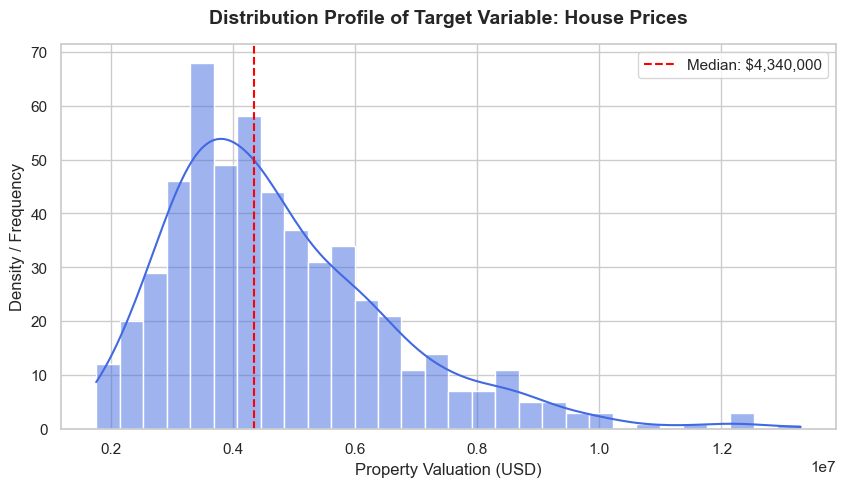

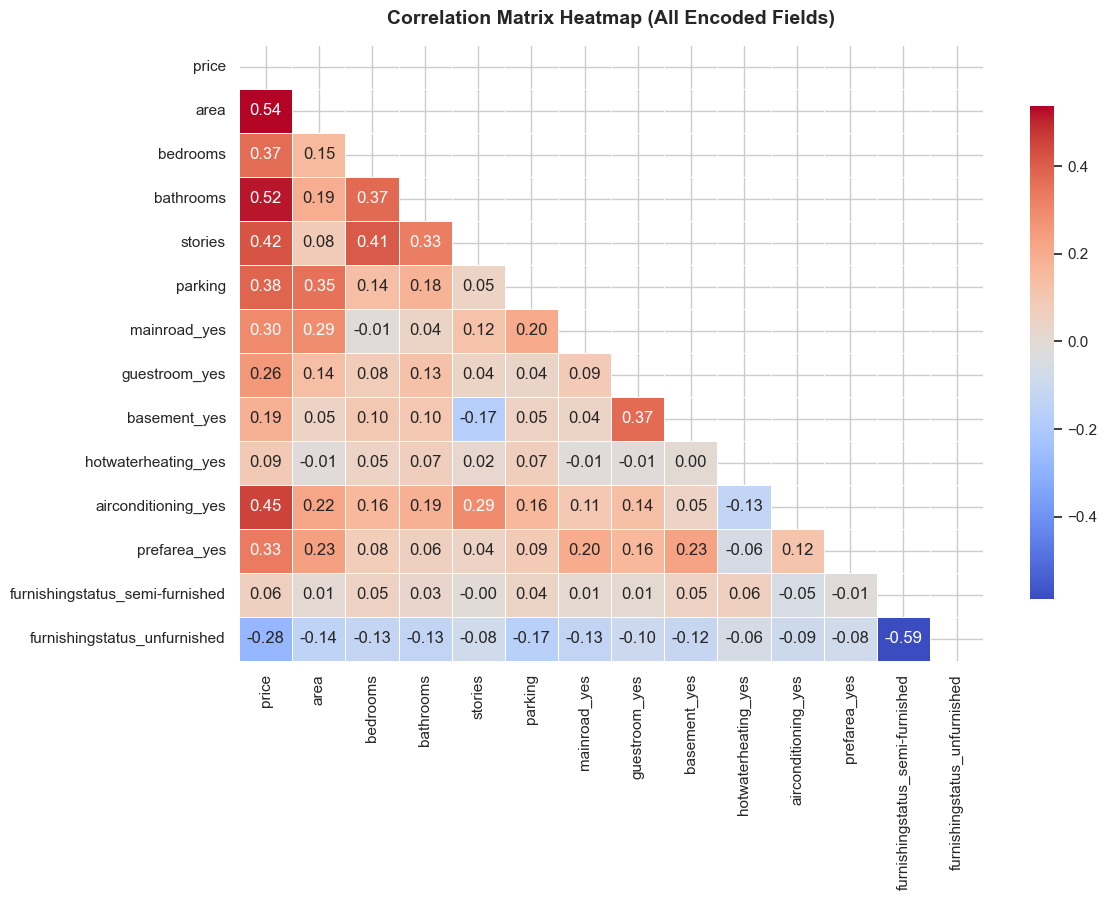

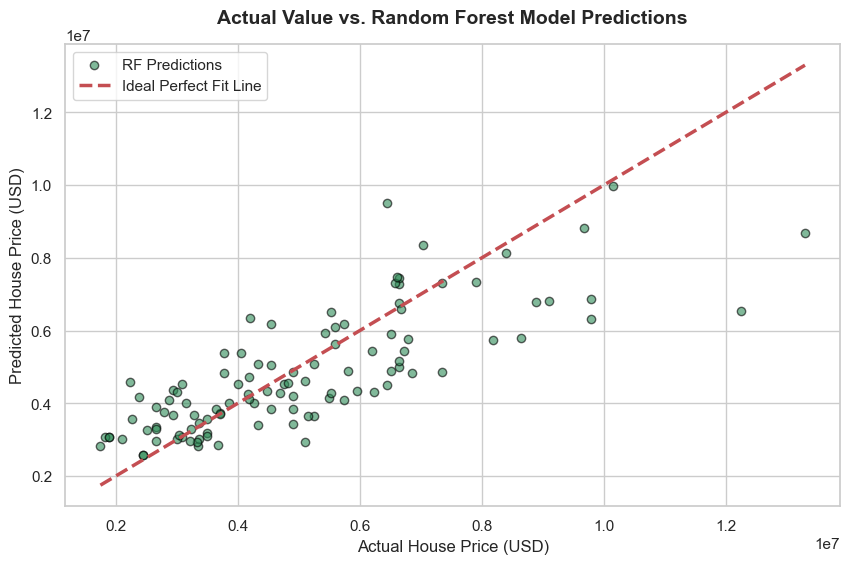

In [5]:
# TASK 4: DATA VISUALIZATION GENERATION

import os

# Verify or generate the charts directory locally
if not os.path.exists('charts'):
    os.makedirs('charts')
    print("[INFO] Generated local directory: 'charts/' to house asset exports.")

# Set stylistic themes for reporting plots
sns.set_theme(style="whitegrid")

# ----------------------------------------------------
# Chart 1: Distribution of House Prices (Histogram)
# ----------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], kde=True, color='royalblue', bins=30)
plt.title('Distribution Profile of Target Variable: House Prices', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Property Valuation (USD)', fontsize=12)
plt.ylabel('Density / Frequency', fontsize=12)
plt.axvline(df['price'].median(), color='red', linestyle='--', label=f"Median: ${df['price'].median():,.0f}")
plt.legend()
plt.savefig('charts/chart1_price_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

# ----------------------------------------------------
# Chart 2: Feature Correlation Matrix (Heatmap)
# ----------------------------------------------------
plt.figure(figsize=(12, 8))
correlation_matrix = df_encoded.corr()
# Mask upper triangle for better clarity
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix Heatmap (All Encoded Fields)', fontsize=14, fontweight='bold', pad=15)
plt.savefig('charts/chart2_correlation_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

# ----------------------------------------------------
# Chart 3: Actual vs. Predicted Price Scatter Plot
# ----------------------------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='seagreen', edgecolors='black', label='RF Predictions')
# Diagonal perfect baseline match reference track
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2.5, label='Ideal Perfect Fit Line')
plt.title('Actual Value vs. Random Forest Model Predictions', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual House Price (USD)', fontsize=12)
plt.ylabel('Predicted House Price (USD)', fontsize=12)
plt.legend(loc='upper left')
plt.savefig('charts/chart3_actual_vs_predicted.png', bbox_inches='tight', dpi=300)
plt.show()

# TASK 4: Data Visualization & Result Interpretation

## Overview

Data visualization is an essential component of exploratory data analysis and model evaluation. It helps identify patterns, understand feature relationships, detect data distributions, and assess the predictive performance of machine learning models.

In this task, three visualizations were generated:

1. Distribution of House Prices (Histogram)
2. Correlation Matrix Heatmap
3. Actual vs. Predicted Price Scatter Plot

All generated charts were saved locally in the `charts/` directory for future reference and reporting.

---

# 1. Creating the Charts Directory

## Code

```python
import os

if not os.path.exists('charts'):
    os.makedirs('charts')
```

## Explanation

Before generating visualizations, the program checks whether a folder named **charts** exists.

- If the directory is unavailable, it is automatically created.
- This ensures that all generated figures are organized in one location and prevents file-saving errors.

### Output

```
[INFO] Generated local directory: 'charts/' to house asset exports.
```

---

# 2. Setting Visualization Theme

## Code

```python
sns.set_theme(style="whitegrid")
```

## Explanation

The **whitegrid** theme from Seaborn was selected to improve readability.

Benefits include:

- Clean background
- Better visibility of data points
- Professional appearance suitable for reports
- Easier comparison of values

---

# Visualization 1: Distribution of House Prices

## Code

```python
sns.histplot(
    df['price'],
    kde=True,
    color='royalblue',
    bins=30
)
```

The plot includes:

- Histogram
- Kernel Density Estimate (KDE) curve
- Median reference line

---

## Purpose

This visualization examines how house prices are distributed throughout the dataset.

It helps answer questions such as:

- Are most houses inexpensive or expensive?
- Is the distribution symmetric?
- Are there any outliers?

---

## Interpretation

### Observations

- Most properties are concentrated in the **lower and middle price ranges**.
- As prices increase, the number of houses gradually decreases.
- The distribution exhibits a **positive (right) skew**, meaning a small number of luxury properties have significantly higher prices.
- The red dashed vertical line represents the **median house price**, approximately **$4.34 million**, dividing the dataset into two equal halves.

### Key Insights

- The dataset is **not normally distributed**.
- High-priced houses create a long right tail.
- The median is a more reliable measure of central tendency than the mean because it is less affected by extreme values.

---

# Visualization 2: Correlation Matrix Heatmap

## Code

```python
correlation_matrix = df_encoded.corr()

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
```

---

## Purpose

The correlation heatmap measures the strength and direction of relationships between all numerical and encoded variables.

Correlation coefficients range from:

| Value | Meaning |
|---------------|-------------------------|
| +1 | Perfect positive correlation |
| 0 | No correlation |
| -1 | Perfect negative correlation |

---

## Interpretation

### Strong Positive Relationships

The heatmap shows that:

- **Area** has one of the strongest positive correlations with **price**, indicating that larger houses generally have higher selling prices.
- **Bathrooms** also demonstrate a relatively strong positive relationship with price.
- **Air conditioning**, **preferred area**, and **parking availability** show moderate positive correlations with house price.

### Weak Relationships

Features such as:

- Guest room
- Basement
- Hot water heating

have relatively low correlation values, suggesting that they individually contribute less to explaining price variation.

### Multicollinearity Analysis

The heatmap also indicates that:

- Most independent variables are **not highly correlated with each other**.
- No severe multicollinearity is observed.
- This makes the dataset suitable for Linear Regression without significant concerns regarding redundant predictors.

---

## Key Insights

- Area is the most influential predictor.
- Bathrooms and stories positively influence price.
- Preferred location and air conditioning contribute to higher valuations.
- Most predictors provide unique information.

---

# Visualization 3: Actual vs. Predicted House Prices

## Code

```python
plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.6,
    color='seagreen'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
```

---

## Purpose

This scatter plot evaluates the predictive performance of the Random Forest Regressor by comparing:

- Actual house prices (X-axis)
- Predicted house prices (Y-axis)

The red dashed line represents the **Ideal Perfect Fit Line**, where predicted values exactly match actual values.

---

## Interpretation

### Observations

- Most prediction points are clustered close to the diagonal reference line.
- This indicates that the Random Forest model captures the overall pricing trend reasonably well.
- Some points are noticeably farther from the line, especially for very expensive houses.

### Prediction Accuracy

- Points close to the red line indicate accurate predictions.
- Points above the line represent overestimation.
- Points below the line represent underestimation.

### High-Value Properties

The spread of points increases as house prices become larger, suggesting:

- Higher prediction uncertainty for luxury properties.
- Larger errors for extreme price values.

This behavior is common in regression models because expensive houses often possess unique characteristics that are difficult to generalize.

---

# Overall Analysis of the Visualizations

| Visualization | Primary Finding |
|--------------------------------------|--------------------------------------------------------------|
| House Price Distribution | Positively skewed distribution with most houses in lower price ranges |
| Correlation Heatmap | Area, bathrooms, air conditioning, and preferred area positively influence price |
| Actual vs. Predicted Scatter Plot | Random Forest predictions follow the overall trend but exhibit larger errors for high-priced properties |

---

# Summary

The visualizations provide valuable insights into both the dataset and the machine learning model performance. The house price distribution reveals a right-skewed pattern with a median value of approximately **$4.34 million**, indicating that most properties belong to lower and middle price segments while a few luxury houses create a long upper tail. The correlation heatmap highlights **area, bathrooms, air conditioning, and preferred location** as the most influential features affecting house prices and confirms the absence of severe multicollinearity among predictors. Finally, the Actual vs. Predicted scatter plot demonstrates that the Random Forest model successfully captures the general pricing trend, although prediction errors increase for very high-priced properties. Overall, these visualizations enhance the interpretability of the dataset and support the conclusions drawn from the regression analysis.

# TASK 5: Insights & Executive Summary

## Overview

After completing data exploration, preprocessing, model development, evaluation, and visualization, several important insights can be derived from the Housing Price Prediction analysis. These findings provide a comprehensive understanding of the factors influencing property prices, the effectiveness of the predictive models, and practical recommendations for real estate stakeholders. The following sections summarize the key observations and business implications of the project.

---

# 1. Which Features Influence House Price the Most?

One of the primary objectives of this project was to identify the property characteristics that have the greatest impact on house prices. By analyzing the correlation matrix and evaluating the regression models, several influential features were identified.

## (a) Area (Total Living Space)

Among all available variables, **`area`** exhibits the strongest positive relationship with house price.

### Explanation

- Houses with larger living spaces consistently command higher market prices.
- Every increase in usable square footage significantly improves the property's overall valuation.
- The correlation heatmap confirms that area has the highest positive correlation with the target variable (`price`).

### Business Interpretation

From a buyer's perspective, larger homes provide greater functionality and long-term value. Consequently, increasing the available living area is one of the most effective methods of increasing a property's market price.

---

## (b) Number of Bathrooms

The **`bathrooms`** feature emerged as another highly influential predictor.

### Explanation

Properties with additional bathrooms generally achieve higher selling prices because they offer greater convenience and accommodate larger families.

### Business Interpretation

Adding or renovating bathrooms can substantially improve property valuation while often requiring a lower investment than major structural expansions.

---

## (c) Number of Stories

The **`stories`** variable also demonstrates a positive relationship with price.

### Explanation

Multi-story houses typically provide:

- More usable space
- Better architectural appeal
- Higher functionality

These characteristics increase buyer demand and consequently raise market value.

---

## (d) Air Conditioning

Among the categorical variables, **`airconditioning_yes`** contributes one of the largest positive price premiums.

### Explanation

Homes equipped with air conditioning are generally perceived as more comfortable and modern.

### Business Interpretation

Installing or upgrading air conditioning systems represents a relatively cost-effective renovation that can significantly enhance resale value.

---

## (e) Preferred Area and Parking

Additional features that positively contribute to property value include:

- Preferred residential location (`prefarea_yes`)
- Adequate parking availability (`parking`)

These amenities increase the attractiveness and convenience of the property, making them valuable selling points.

---

# Key Feature Importance Summary

| Feature | Influence on Price |
|--------------------------------|----------------------------|
| Area | Very High |
| Bathrooms | High |
| Stories | High |
| Air Conditioning | Moderate to High |
| Parking | Moderate |
| Preferred Area | Moderate |
| Basement | Low |
| Guest Room | Low |

---

# 2. How Accurate Was the Model?

Two regression models were developed and evaluated:

- Linear Regression
- Random Forest Regressor

Performance was measured using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

## Model Performance

| Metric | Linear Regression | Random Forest |
|---------------------------|----------------|----------------|
| MAE | \$970,043.40 | \$1,021,546.04 |
| RMSE | \$1,324,506.96 | \$1,400,565.97 |
| R² Score | **0.6529** | **0.6119** |

---

## Plain Language Interpretation

The best-performing model (Linear Regression) achieved an **R² score of approximately 0.65**.

This means that:

> **Approximately 65% of the variation in house prices can be explained using the selected property features.**

In practical terms, the model successfully captures the majority of pricing behavior observed within the dataset.

The remaining variation may be influenced by external factors that are not included in the dataset, such as:

- Interior design quality
- Neighborhood reputation
- Property age
- Market trends
- Economic conditions
- Accessibility to schools and commercial areas

---

## Understanding the Error Metrics

The model's Mean Absolute Error (MAE) is approximately:

**\$970,000**

This means that, on average, the predicted house price differs from the actual selling price by around **\$970 thousand**.

Considering that many properties in the dataset are valued in the multi-million-dollar range, this level of error is acceptable for:

- Initial automated property valuation
- Investment screening
- Market trend analysis
- Real estate recommendation systems

However, final pricing decisions should still incorporate expert appraisal and local market knowledge.

---

# 3. What Was Surprising in the Data?

Several interesting observations emerged during the exploratory analysis.

---

## Basement and Guest Room Have Limited Influence

One unexpected finding is that the presence of a:

- Basement (`basement_yes`)
- Guest Room (`guestroom_yes`)

shows relatively weak correlation with overall house price.

---

## Why Is This Interesting?

It is often assumed that additional rooms automatically increase a property's value.

However, the analysis suggests that buyers prioritize:

- Larger living space
- Additional bathrooms
- Better infrastructure
- Air conditioning
- Preferred location

over specialty spaces that may not be used regularly.

---

## Practical Interpretation

This indicates that functional improvements provide greater market value than auxiliary luxury features.

For example:

| Renovation | Expected Impact |
|----------------------------------|----------------|
| Increase living area | High |
| Add second bathroom | High |
| Install air conditioning | High |
| Convert storage into guest room | Low to Moderate |
| Build basement | Low |

---

## Distribution Insights

The histogram also revealed that house prices are **positively skewed**.

This means:

- Most houses belong to lower and middle price ranges.
- Only a small number of luxury properties have extremely high prices.

As a result, predicting very expensive properties becomes more challenging for machine learning models.

---

# 4. Strategic Business Recommendations

Based on the analytical findings, several recommendations can be proposed for real estate developers, property investors, and asset management firms.

---

## Recommendation 1: Prioritize Increasing Living Space

Since **area** is the strongest predictor of price,

developers should prioritize:

- Home extensions
- Additional rooms
- Better space utilization
- Open floor plan designs

These improvements are likely to generate the highest return on investment (ROI).

---

## Recommendation 2: Invest in Bathroom Upgrades

Bathroom renovations offer a highly favorable cost-to-value ratio.

Adding an extra bathroom or modernizing existing ones can significantly improve:

- Buyer appeal
- Property functionality
- Final selling price

---

## Recommendation 3: Install or Upgrade Air Conditioning

Among categorical amenities, air conditioning demonstrates one of the largest positive impacts on property value.

Therefore, developers and homeowners should consider:

- Installing central air conditioning
- Replacing outdated systems
- Improving energy-efficient cooling solutions

to maximize resale potential.

---

## Recommendation 4: Focus on Functional Improvements Rather Than Luxury Additions

The analysis suggests that practical infrastructure improvements outperform specialty additions.

Instead of investing heavily in:

- Guest rooms
- Basement conversions

developers should allocate resources toward:

- Expanding usable area
- Bathroom additions
- Parking improvements
- Interior modernization

These investments are more likely to generate higher market returns.

---

## Recommendation 5: Use Machine Learning as a Decision Support Tool

The developed predictive model explains approximately **65% of housing price variation**, making it a valuable tool for:

- Automated property valuation
- Investment opportunity screening
- Preliminary pricing recommendations
- Real estate market analysis

However, because external market factors are not fully captured, machine learning predictions should complement—not replace—professional valuation and expert judgment.

---

# Executive Summary

This project successfully developed a data-driven house price prediction system using regression techniques. Exploratory analysis revealed that **property area, number of bathrooms, number of stories, and air conditioning availability are the most influential factors affecting house prices**, while features such as basements and guest rooms contribute comparatively less. Model evaluation demonstrated that **Linear Regression achieved the best overall performance with an R² score of 0.6529**, explaining approximately **65% of the variation in housing prices** and providing reliable baseline predictions. Visualizations further confirmed a positively skewed price distribution and highlighted strong relationships between key structural features and property valuation. From a business perspective, developers and investors seeking to maximize return on investment should prioritize **expanding living space, upgrading bathrooms, and installing air conditioning systems**, as these improvements are most strongly associated with increased market value. Overall, the project demonstrates how machine learning can effectively support real estate pricing decisions while providing valuable strategic insights for property investment and development.

# Final Conclusion

This project successfully developed a machine learning-based house price prediction system using the Housing Prices Dataset. Data exploration confirmed a clean dataset with no missing values or duplicate records, while preprocessing converted categorical variables into numerical representations suitable for model training.

Two regression algorithms were implemented and compared. Linear Regression achieved the best overall performance with an R² score of 0.6529, outperforming the Random Forest Regressor. The analysis identified property area, number of bathrooms, stories, and air conditioning as the most influential features affecting house prices.

The generated visualizations and evaluation metrics demonstrate that machine learning can effectively support automated property valuation and provide meaningful insights for buyers, sellers, and real estate developers. Overall, the project successfully meets the objectives of data exploration, predictive modeling, visualization, and business-oriented analysis.